In [81]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [82]:
N = 500
nt = 100
m = 5

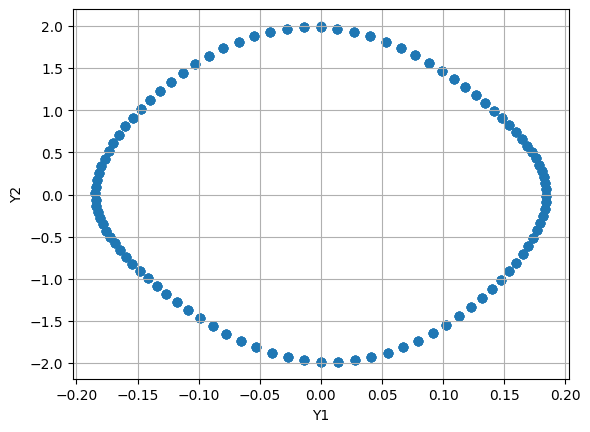

In [83]:
def g(y, t):
    q = 0.5
    b = 0.9
    omega0 = 2.0/3

    v = np.zeros(2)
    v[0] = y[1]                                             # q 
    v[1] = -math.sin(y[0]) + b*math.cos(omega0*t) - q*y[1]  # q'
    return v


def rungeKutta(Y, t, dt):
    C1 = g(Y, t)
    C2 = g(Y + dt*C1/2, t + dt/2)
    C3 = g(Y + dt*C2/2, t + dt/2)
    C4 = g(Y + dt*C3,   t + dt)

    return Y + dt*(C1 + 2*C2 + 2*C3 + C4)/6


DT = 3*math.pi/nt

Y1 = np.zeros(N+1)
Y2 = np.zeros(N+1)

Y = np.zeros(2)
Y2[0]=Y1[1]=2


# Scarto il transitorio
# (In effetti non è detto che le condizioni iniziali appartengono
# all'attrattore, dunque svoglo delle iterazioni per raggiungerlo)
for i in range(1000):
    t = DT*i
    Y = rungeKutta(Y, t, DT)

for i in range(N):
    t = DT*i
    Y = rungeKutta(Y, t, DT)

    Y1[i+1] = Y[0]
    Y2[i+1] = Y[1]

    k = (Y1[i+1] / (2*math.pi + 0.5))
    Y1[i+1] -= (2*math.pi)*k


plt.scatter(Y1, Y2)
plt.xlabel("Y1")
plt.ylabel("Y2")
plt.grid(True)
plt.show()